###### <h1 align=center> CRIBADO PRENATAL (I) </h1>

In [1]:
#Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm 

from sklearn import metrics,impute
import random


import warnings
warnings.filterwarnings("ignore")

In [2]:
control=pd.read_excel("./BaseDatosSdDown/BaseDatos_TFM_David_2026_FIN.xls")
caso=pd.read_excel("./BaseDatosSdDown/BaseDatos_TFM_David_2026_FIN.xls",sheet_name=2,na_values=["calcX","\t"])
df=pd.concat([control,caso]).reset_index(drop=True)
norm=pd.read_excel('./BaseDatosSdDown/BaseDatos_TFM_David_2026_FIN.xls',sheet_name=1) #Valores normales según (INTERGROWTH?)
b={'SI':1,'NO':0}
df.replace({'mEN':b,'mAUU':b,'mPRB':b,'mIHE':b,'mvvll':b,
           'mCOR':b,'mDIG':b,'mOTR':b},inplace=True) #Codificación de categóricas
df=df.convert_dtypes()
df.CRL=df.CRL//1

df.CLASE=df.CLASE.astype('category')
df=df.drop(columns="PARTOEGSEM")
df=df.loc[df.identificacion.notna()] #ID nula fuera

1 identificación fuera, 
Agrupar datos de 1T y 2T, con tal de tener 1 por embarazo habría que agregar los de 2T por el más completo y cercano a S20


todos los fetos afectos han sido diagnosticados con un cariotipo y/o QF-PCR (prueba que detecta la trisomía 21, entre otras aneuploidías)
Se consideran dos separaciones según 1T o 2T y datos relativos a la madre.

In [3]:
df["identificacion"]=df['identificacion'].str.split('.').str[0] #Separamos las copias de instancias "ID.1"
T1=df.iloc[:,[1]+list(range(13,18))].drop_duplicates(subset="identificacion")\
    .dropna(subset="EGscreeningPrimerTrimestre").set_index("identificacion")  #Nos quedamos con las instancias únicas 
Madre=df.loc[:,["identificacion","CLASE","EDADmadre","TALLAmadre","PESOmadre"]].drop_duplicates(subset="identificacion").set_index("identificacion")
Madre.CLASE=Madre.CLASE.astype('category')
Madre.isna().mean()

CLASE         0.000000
EDADmadre     0.001461
TALLAmadre    0.200511
PESOmadre     0.197589
dtype: float64

Falta un 20% de Talla y Peso, pero como se utizará para corregir, no es necesario imputar.

- mEN: espesor nucal aumentado
- mAUU: arteria umbilical única
- mPRB: pielectasia renal bilateral
- mIHE: intestino hiperecoge..
- mvvll: ventriculomegalia cerebral
- mCOR: cardiopatía congénita
- mDIG: anomalía digestiva
- mOTR: otras anomalías estructurales ligadas a cromosomopatías.
- PAPPA y HCG según EG -> logMoM corregir según volumen de distribución.

In [4]:
#Imputación EDAD faltante en Madre
Madre=Madre.astype({"CLASE":str,"EDADmadre":float,"TALLAmadre":float,"PESOmadre":float})
Madre=Madre.fillna({
    "EDADmadre":Madre.EDADmadre.median(),
}) 

T2=df.iloc[:,[1]+list(range(18,23))+list(range(5,13))].dropna(subset="EdadGestInstanciaActual") #Segundo trimestre
T2["nulls"]=T2.notna().sum(1) #Cuantos tiene en cada registro, para quedarnos con los más completos y S20
T2["S20_dist"]=abs(T2.EdadGestInstanciaActual-20*7) #Distancia a la semana 20
T2=T2.sort_values(["identificacion","nulls","S20_dist"],ascending=[True, True, False])\
    .groupby("identificacion").last().drop(columns=["nulls","S20_dist"])
T2=T2.convert_dtypes()

<h1> Faltantes e Inconsistentes</h1>

In [5]:
T1.loc[T1.isna().any(axis=1),:] #Sólo hay 2 registros sin CRL sn
T1=T1.dropna()
#Sólo hay 1 registro con LF faltante
T2[T2.LF.isna()]
T2=T2.dropna()

<h2> MoM INTERGROWTH</h2>

In [6]:
T1_MED=norm.iloc[:,0:3].dropna().astype("int").set_index("EGscreeningPrimerTrimestre")
sn_MED=norm.iloc[:,4:6].dropna().astype({"CRL":"int"}).set_index("CRL")
T2_MED=norm.iloc[:,7:].dropna().set_index("EdadGestInstanciaActual")


In [7]:
#T1_1 son PAPPA HCG y sn normalizadas por log MoM.
T1_1=T1.join(T1_MED,on="EGscreeningPrimerTrimestre",how="left") #anexionamos T1_med
T1_1["PAPPA_LMoM"]=np.log(T1_1.PAPPA/T1_1["PAPP-A_Mediana"])#Log MoM Pappa
T1_1["HCG_LMoM"]=np.log(T1_1.HCG1T/T1_1["HCG_Mediana"])#Log MoM HCG
T1_1=T1_1.join(sn_MED,on="CRL",how="left")
T1_1["sn_LMoM"]=np.log(T1_1.sn/T1_1["sn_Mediana"]) #Log MoM sn
T1_1=T1_1.loc[:,["PAPPA_LMoM","HCG_LMoM","sn_LMoM"]]

T2_1=T2.join(T2_MED,on="EdadGestInstanciaActual",how="left")\
.assign(DBP=lambda x: np.log(x["DBP"]/x["DBP_Mediana"]),
       PER_CEFAL=lambda x: np.log(x["PER_CEFAL"]/x["PER_CEFAL_Mediana"]),
       PER_ABDOM=lambda x: np.log(x["PER_ABDOM"]/x["PER_ABDOM_Mediana"]),
       LF=lambda x: np.log(x["LF"]/x["LF_Mediana"]))\
.drop(columns=["EdadGestInstanciaActual","DBP_Mediana","PER_CEFAL_Mediana","PER_ABDOM_Mediana","LF_Mediana"]).dropna()

<h2>Cuántos datos tenemos?</h2>

In [8]:
T1_idx=set(T1_1.index)
T2_idx=set(T2_1.index)
Madre=Madre.loc[list(T1_idx | T2_idx)] #Eliminamos Madres que no tienen registros
T1_SD_idx=set(T1_1.join(Madre,how="left").query("CLASE=='claseSdDown'").index)
T2_SD_idx=set(T2_1.join(Madre,how="left").query("CLASE=='claseSdDown'").index)

print(f"{len(T1_SD_idx | T2_SD_idx)} Casos afectos: {len(T1_SD_idx & T2_SD_idx)}"+
      f" completos, {len(T1_SD_idx-T2_SD_idx )} sólo con T1, {len(T2_SD_idx-T1_SD_idx)} sólo con T2") 
print(f"{len((T1_idx |T2_idx)-(T1_SD_idx | T2_SD_idx))} Casos control: "+
      f"{len((T1_idx &T2_idx)-(T1_SD_idx | T2_SD_idx))}"+
      f" completos, {len((T1_idx -T2_idx)-(T1_SD_idx | T2_SD_idx))} "+
      f"sólo con T1, {len((T2_idx -T1_idx)-(T1_SD_idx | T2_SD_idx))} sólo con T2") 


139 Casos afectos: 78 completos, 22 sólo con T1, 39 sólo con T2
2599 Casos control: 1958 completos, 641 sólo con T1, 0 sólo con T2


<img src="../Venn.png" alt="Venn" width="300" height="300" style="display:block;margin:auto"/>

Reservamos el 20% estratificado de los registros completos para el TEST FINAL

In [9]:
random.seed(777)
test_sd_idx=random.sample(sorted(T1_SD_idx & T2_SD_idx),round(0.2*len(T1_SD_idx & T2_SD_idx)))

test_control_idx=random.sample(sorted((T1_idx-T1_SD_idx) & (T2_idx -T2_SD_idx )),
                              round(0.2*len((T1_idx-T1_SD_idx) & (T2_idx -T2_SD_idx ))))

TEST=(set(test_sd_idx) | set(test_control_idx))

In [10]:
#Imputación de Madre
knn=impute.KNNImputer()
train_set=(T1_idx|T2_idx)-TEST
Madre.loc[list(train_set),"EDADmadre":]=knn.fit_transform(Madre.loc[list(train_set),"EDADmadre":]) #Train
Madre.loc[list(TEST),"EDADmadre":]=knn.transform(Madre.loc[list(TEST),"EDADmadre":]) #Test


<h2>CORRECCIÓN PESO 1T</h2>

El peso tiene un efecto significativo en PAPPA_LMoM, se propone la siguiente corrección.
$$
\begin{array}\
\log\text{MoM}=4.1374-0.9934·\log{PESO}+\varepsilon\\
\varepsilon=\log\text{MoM}-(4.1374-0.9934·\log{PESO})\\
\end{array}
$$

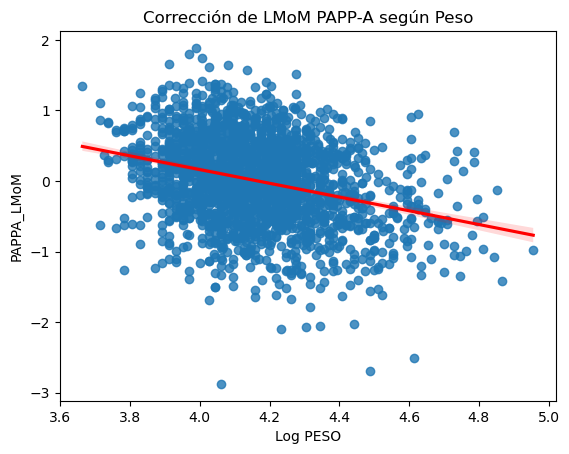

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.089
Model:                            OLS   Adj. R-squared:                  0.089
Method:                 Least Squares   F-statistic:                     216.6
Date:                Fri, 01 May 2026   Prob (F-statistic):           7.86e-47
Time:                        21:12:21   Log-Likelihood:                -1918.1
No. Observations:                2207   AIC:                             3840.
Df Residuals:                    2205   BIC:                             3852.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.0556      0.276     14.717      0.0

In [11]:
aux=T1_1.loc[list(T1_idx-TEST)].join(Madre.loc[Madre.CLASE=="claseControl"],how="inner").copy()
# Ajustar modelo
X = sm.add_constant(np.asarray(np.log(aux["PESOmadre"])))
model = sm.OLS(np.asarray(aux["PAPPA_LMoM"]), X,missing="drop").fit()


(a1 := sns.regplot(aux,x=np.log(aux["PESOmadre"]),y="PAPPA_LMoM",
           line_kws={"color":"red"}))
plt.xlabel("Log PESO")
plt.title("Corrección de LMoM PAPP-A según Peso")
plt.show()
print(model.summary())
#Corrección
aux=T1_1.join(Madre,how="left").copy()
T1_1["PAPPA_LMoM"]=(aux["PAPPA_LMoM"]-(model.params[0]+model.params[1]*np.log(aux["PESOmadre"])))

El peso tiene un efecto significativo en HCG_LMoM, se propone la siguiente corrección.
$$
\begin{array}\
\log\text{MoM}=3.3045--0.8001·\log{PESO}+\varepsilon\\
\varepsilon=\log\text{MoM}-(3.3045-0.8001·\log{PESO})\\
\end{array}
$$

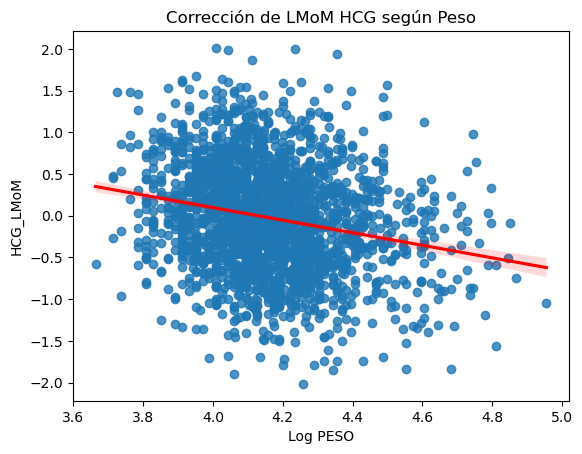

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     109.2
Date:                Fri, 01 May 2026   Prob (F-statistic):           5.61e-25
Time:                        21:12:21   Log-Likelihood:                -2103.3
No. Observations:                2207   AIC:                             4211.
Df Residuals:                    2205   BIC:                             4222.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.1039      0.300     10.357      0.0

In [12]:

aux=T1_1.loc[list(T1_idx-TEST)].join(Madre.loc[Madre.CLASE=="claseControl"],how="inner").copy()
# Ajustar modelo
X = sm.add_constant(np.asarray(np.log(aux["PESOmadre"])))
model = sm.OLS(np.asarray(aux["HCG_LMoM"]), X).fit()


(a2 := sns.regplot(aux,x=np.log(aux["PESOmadre"]),y="HCG_LMoM",
           line_kws={"color":"red"}))
plt.xlabel("Log PESO")
plt.title("Corrección de LMoM HCG según Peso")
plt.show()
print(model.summary())
#Corrección
aux=T1_1.join(Madre,how="left").copy()
T1_1["HCG_LMoM"]=(aux["HCG_LMoM"]-(model.params[0]+model.params[1]*np.log(aux["PESOmadre"])))

In [13]:
T2_1=T2.join(T2_MED,on="EdadGestInstanciaActual",how="left")\
.assign(DBP=lambda x: np.log(x["DBP"]/x["DBP_Mediana"]),
       PER_CEFAL=lambda x: np.log(x["PER_CEFAL"]/x["PER_CEFAL_Mediana"]),
       PER_ABDOM=lambda x: np.log(x["PER_ABDOM"]/x["PER_ABDOM_Mediana"]),
       LF=lambda x: np.log(x["LF"]/x["LF_Mediana"]))\
.drop(columns=["EdadGestInstanciaActual","DBP_Mediana","PER_CEFAL_Mediana","PER_ABDOM_Mediana","LF_Mediana"])

<h2>OUTLIERS</h2>
1- $Me \pm 5.1891·MAD$


2- Log Mom ~ N(0,$\sigma$), luego estimamos con población control y los que caigan fuera del 99%

In [14]:
def threshold_LMoM(x,alpha=0.01):
    sigma=np.std(x,ddof=1)
    return stats.norm.ppf(1-alpha/2,0,sigma)
def MAD(x,z=3.5): 
    med=np.median(x)
    mad=np.median(np.abs(x-med))
    return [med-z*1.4826*mad,med+z*1.4826*mad]

PAPPA_LMoM [np.float64(-2.0424553162414067), np.float64(2.044925698782799)]
HCG_LMoM [np.float64(-2.2624779944914994), np.float64(2.2689983560755156)]
sn_LMoM [np.float64(-0.9976528828027261), np.float64(0.7808342857883565)]


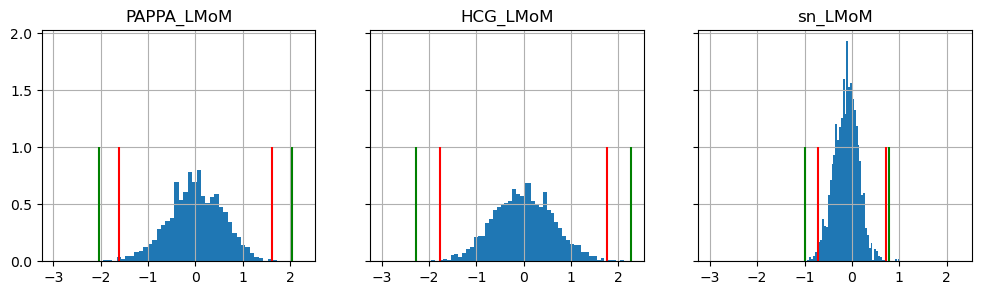

In [15]:
fig,ax=plt.subplots(1,3,sharey=True,figsize=(12,3),sharex=True)
for n,i in enumerate(["PAPPA_LMoM","HCG_LMoM","sn_LMoM"]):
    aux=T1_1.loc[list((T1_idx-TEST)-T1_SD_idx),i] #T1 train, controles
    r=threshold_LMoM(aux,alpha=0.005)
    s1,s2=MAD(aux)
    aux.hist(bins=50,density=True,ax=ax[n])
    ax[n].set_title(i)
    ax[n].vlines(x=[-r,r],ymin=0,ymax=1,color='red')
    ax[n].vlines(x=[s1,s2],ymin=0,ymax=1,color='green')
    print(i,[s1,s2])
    #Corrección según MAD
    T1_1.loc[:,i]=np.clip(T1_1.loc[:,i],s1,s2)
    
plt.show()

DBP [np.float64(-0.1845987404243517), np.float64(0.17322244993365593)]
PER_CEFAL [np.float64(-0.14549904982590556), np.float64(0.16907242356648333)]
PER_ABDOM [np.float64(-0.21348280212279055), np.float64(0.18342874700061143)]
LF [np.float64(-0.1695557883862342), np.float64(0.21216094979397054)]


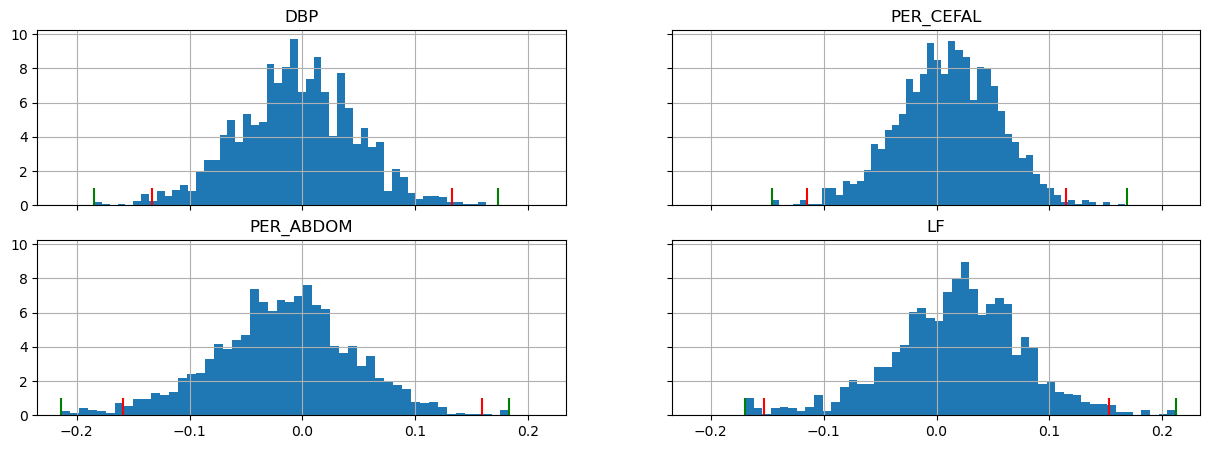

In [17]:
fig,ax=plt.subplots(2,2,sharey=True,figsize=(15,5),sharex=True)
for n,i in enumerate(["DBP","PER_CEFAL","PER_ABDOM","LF"]):
    aux=T2_1.loc[list((T2_idx-TEST)-T2_SD_idx),i]
    r=threshold_LMoM(aux)
    s1,s2=MAD(aux)
    aux.hist(bins=50,density=True,ax=ax[n//2,n%2])
    ax[n//2,n%2].set_title(i)
    ax[n//2,n%2].vlines(x=[-r,r],ymin=0,ymax=1,color='red')
    ax[n//2,n%2].vlines(x=[s1,s2],ymin=0,ymax=1,color='green')
    print(i,[s1,s2])
    #Corrección según MAD
    T2_1.loc[:,i]=np.clip(T2_1.loc[:,i],s1,s2)

plt.show()

<h2 align=center> ANÁLISIS EXPLORATORIO </h2>

In [17]:
#Tabla de frecuencias Clase vs m_
T2_1.loc[list(T2_idx-TEST),"mEN":"mOTR"].groupby(Madre.CLASE).sum()

,mEN,mAUU,mPRB,mIHE,mvvll,mCOR,mDIG,mOTR
CLASE,,,,,,,,
claseControl,1,16,24,12,13,1,0,3
claseSdDown,6,2,12,8,2,13,3,11


- Histogramas por clase para ver separabilidad, AUC=$P(X_{caso}>X_{control})$
- Correlaciones

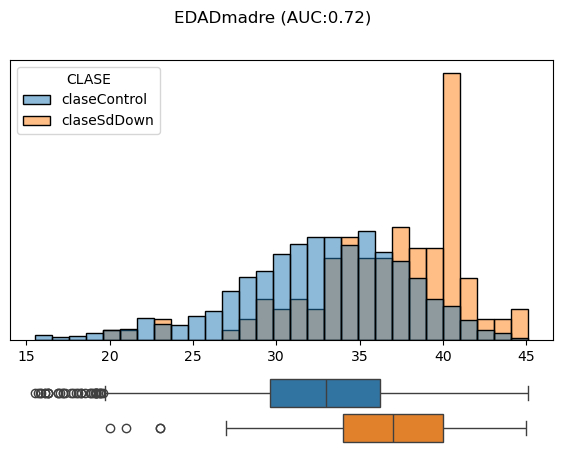

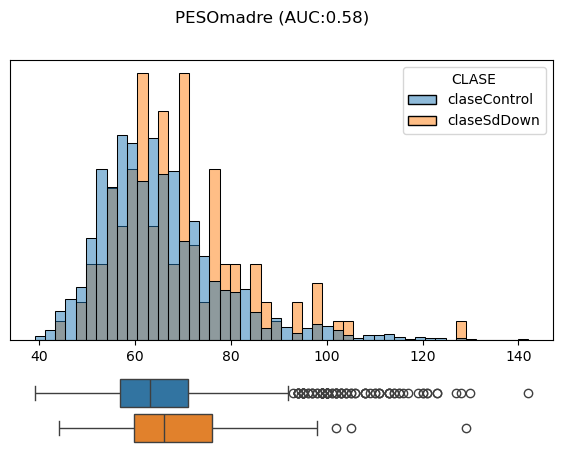

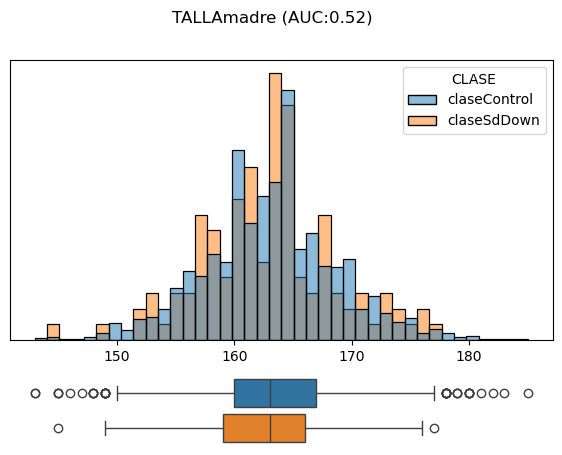

In [18]:
for i in ["EDADmadre","PESOmadre","TALLAmadre"]:
    fig,ax=plt.subplots(2,1,figsize=(7,5),gridspec_kw={'height_ratios':(.8,.2)})
    aux=Madre.loc[list((T1_idx|T2_idx)-TEST)]
    auc=metrics.roc_auc_score(aux.CLASE,aux[i])
    
    
    fig.suptitle(i+ f" (AUC:{np.round(max(auc,1-auc),2)})")
    sns.histplot(data=aux,x=i,hue='CLASE',stat='density',
                 common_norm=False,ax=ax[0])
    sns.boxplot(data=aux,x=i,y='CLASE',hue="CLASE",ax=ax[1])
    ax[0].axes.get_yaxis().set_visible(False)
    ax[0].set_xlabel("")
    ax[1].set_axis_off()
    plt.show()


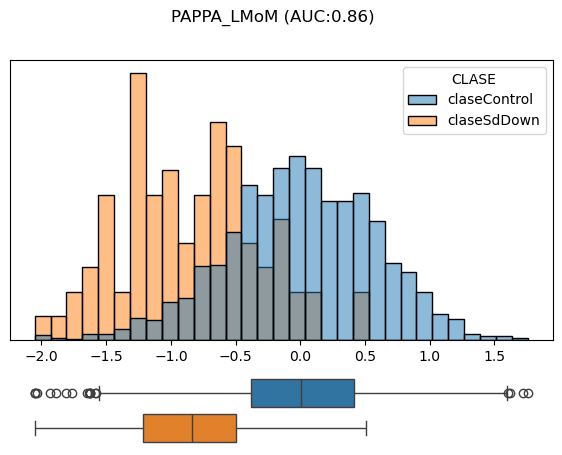

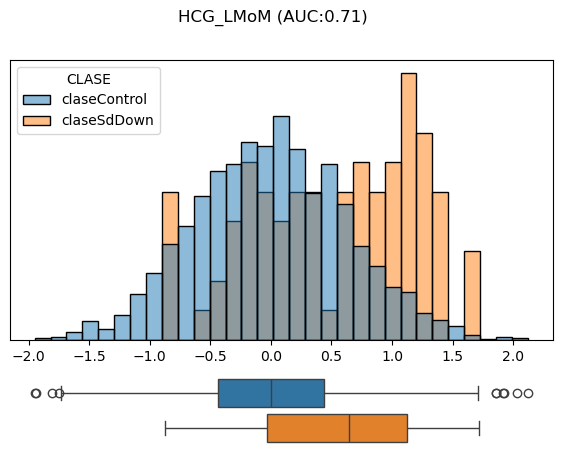

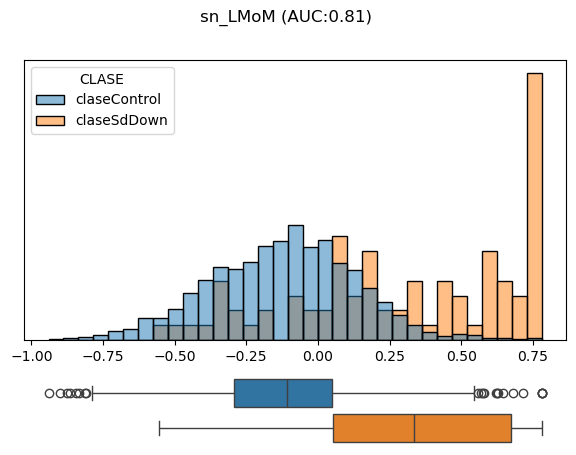

In [19]:
for i in ["PAPPA_LMoM","HCG_LMoM","sn_LMoM"]:
    fig,ax=plt.subplots(2,1,figsize=(7,5),gridspec_kw={'height_ratios':(.8,.2)})
    aux=T1_1.loc[list(T1_idx-TEST)]
    auc=metrics.roc_auc_score(Madre.loc[aux.index].CLASE,aux[i])
    
    
    fig.suptitle(i+ f" (AUC:{np.round(max(auc,1-auc),2)})")
    sns.histplot(data=aux.join(Madre, how="left"),x=i,hue='CLASE',stat='density',
                 common_norm=False,ax=ax[0])
    sns.boxplot(data=aux.join(Madre, how="left"),x=i,y='CLASE',hue="CLASE",ax=ax[1])
    ax[0].axes.get_yaxis().set_visible(False)
    ax[0].set_xlabel("")
    ax[1].set_axis_off()
    plt.show()

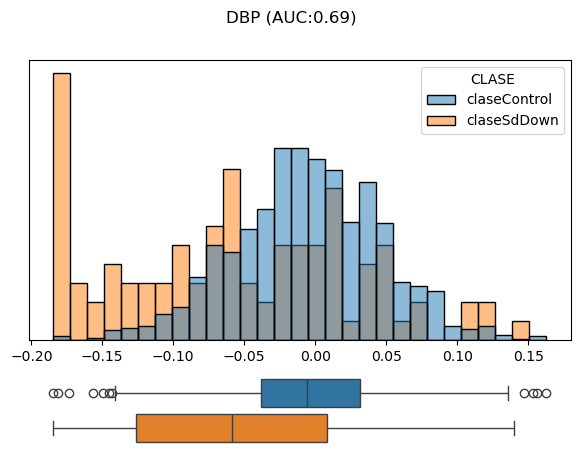

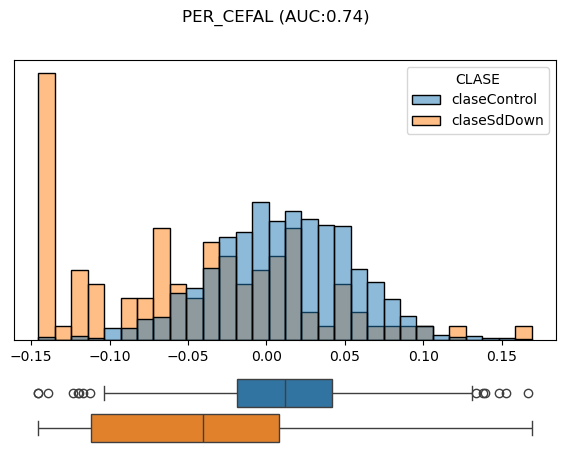

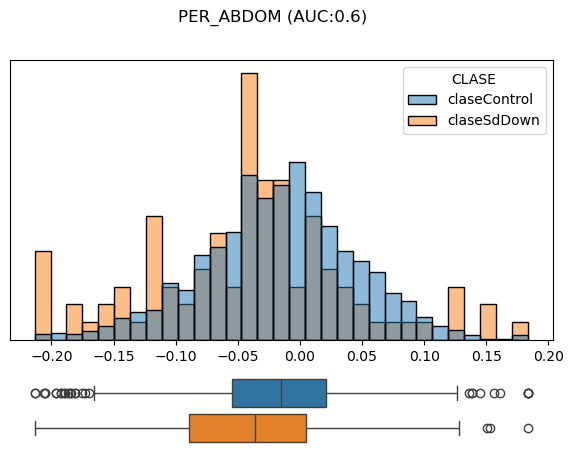

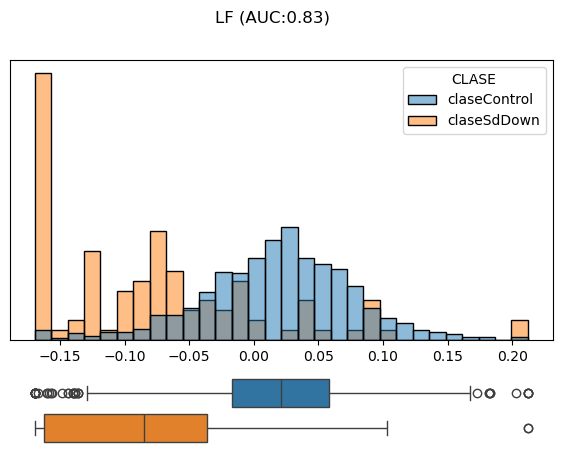

In [20]:
for i in ["DBP","PER_CEFAL","PER_ABDOM","LF"]:
    fig,ax=plt.subplots(2,1,figsize=(7,5),gridspec_kw={'height_ratios':(.8,.2)})
    aux=T2_1.loc[list(T2_idx-TEST)]
    auc=metrics.roc_auc_score(Madre.loc[aux.index].CLASE,aux[i])
    
    
    fig.suptitle(i+ f" (AUC:{np.round(max(auc,1-auc),2)})")
    sns.histplot(data=aux.join(Madre, how="left"),x=i,hue='CLASE',stat='density',
                 common_norm=False,ax=ax[0])
    sns.boxplot(data=aux.join(Madre, how="left"),x=i,y='CLASE',hue="CLASE",ax=ax[1])
    ax[0].axes.get_yaxis().set_visible(False)
    ax[0].set_xlabel("")
    ax[1].set_axis_off()
    plt.show()

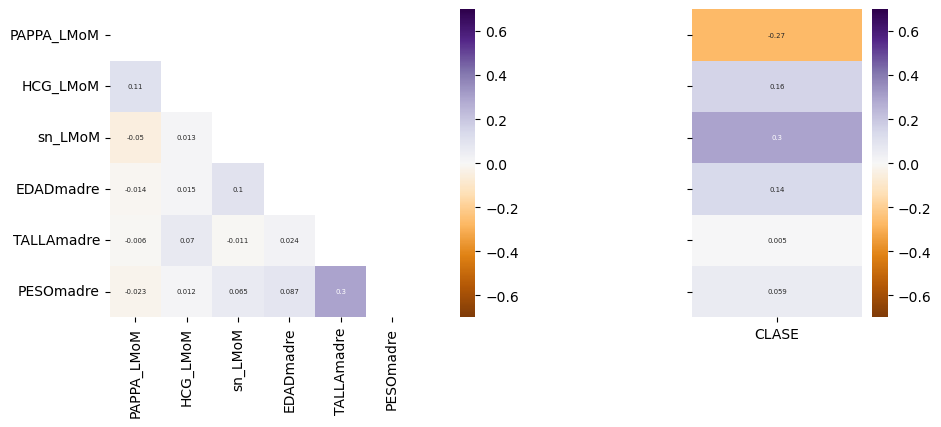

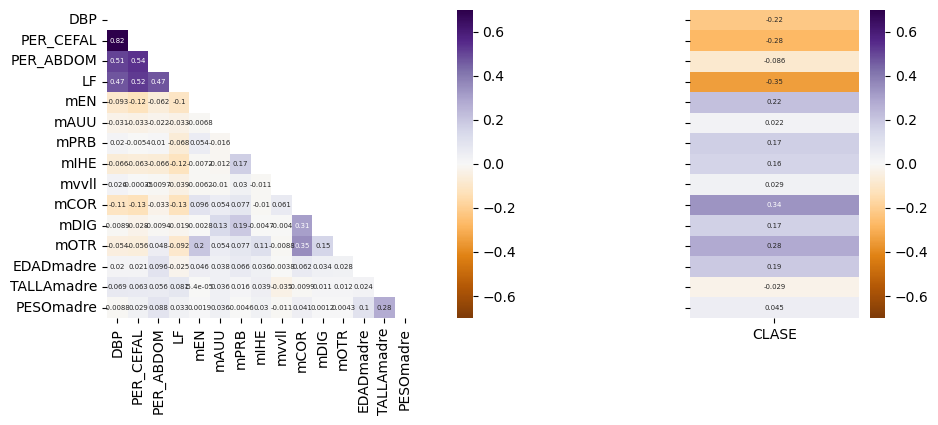

In [21]:
def corrplot(X):

    corr=X.drop(columns='CLASE').corr()
    mask=np.zeros_like(corr,dtype=bool)
    mask[np.triu_indices_from(mask)]=True
    
    fig,ax=plt.subplots(1,2,figsize=(15,4),gridspec_kw={'width_ratios':(.8,.2)},
                       sharey=True)
    
    sns.heatmap(corr,annot=True,mask=mask,center=0,vmin=-0.7,vmax=0.7,
               cmap=plt.cm.PuOr,square=True,annot_kws={'size':5},ax=ax[0])
    
    Y_corr=pd.DataFrame(data=np.zeros((1,corr.shape[0])),columns=corr.columns)
    Y_corr.index=['CLASE']
    for i in corr.columns:
        Y_corr[i]=round(stats.pointbiserialr(y=X[i],x=X.CLASE.cat.codes)[0],3)
    
    sns.heatmap(Y_corr.T,annot=True,center=0,vmin=-0.7,vmax=0.7,
               cmap=plt.cm.PuOr,annot_kws={'size':5},ax=ax[1])
Madre.CLASE=Madre.CLASE.astype('category')
corrplot(T1_1.loc[list(T1_idx-TEST)].join(Madre,how="left"))
corrplot(T2_1.loc[list(T2_idx-TEST)].join(Madre, how="left"))

Se sugiere introducir las variables DBP LMoM - Per_abd LMoM para ver si la diferencia, ratio en variable es discriminante


In [22]:
Madre.to_csv('./BBDD/Madre.csv')
T1_1.loc[list(T1_idx-TEST)].to_csv('./BBDD/T1_MoM.csv')
T2_1.loc[list(T2_idx-TEST)].to_csv('./BBDD/T2_MoM.csv')
T1_1.join(T2_1,how="inner").loc[list(TEST)].to_csv('./BBDD/TEST.csv')


